# CPR / Behavioural Model
## Major European G-SIB | ALM Python Portfolio — Project 7
---
### Overview
This notebook implements a **CPR (Constant Prepayment Rate) Behavioural Model**, the
statistical framework banks use to quantify how early loan repayments affect income
and interest rate risk across rate scenarios.
All figures are in **EUR millions (€m)** unless stated otherwise.
### Business context
Under **EBA/GL/2022/14 (IRRBB Guidelines)**, banks must model borrower behaviour
explicitly — prepayment speed is not fixed, it changes with rates:
- When rates **fall** → borrowers refinance early → loans reprice to lower yields → **NII falls**
- When rates **rise** → borrowers hold cheap fixed mortgages → fewer prepayments → **NII upside limited**
- Faster prepayments **shorten effective duration** → reduces EVE sensitivity to rate shocks
This creates the central ALM tension: the same CPR that helps EVE simultaneously
hurts NII, and vice versa. The ALCO must monitor and hedge both dimensions.
### What this notebook produces
1. Yield delta by scenario — net change in reinvestment yield vs 2025A book rate
2. Part A — NII Sensitivity Grid across 7 CPR levels and 4 rate scenarios
3. Part B — EVE Duration-Shortening Table at Parallel Up +200 bps
4. Two professional finance charts — NII sensitivity lines and EVE bar chart
5. Cross-check vs Excel Section 16
---
*Balance sheet: Major European G-SIB (anonymised) | Reference year: 2026F*

In [1]:
import pandas as pd           # DataFrames for results tables
import numpy as np            # numerical arrays and operations
import matplotlib.pyplot as plt  # charts and visualisations
import matplotlib.ticker as mticker  # axis formatting (percentage, €m)
from matplotlib.patches import FancyBboxPatch  # decorative annotation boxes

# ── Professional quant-finance chart style (Bloomberg / GS research look) ──
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    'white',
    'axes.edgecolor':    '#CCCCCC',
    'axes.grid':         True,
    'grid.color':        '#E8E8E8',
    'grid.linewidth':    0.7,
    'font.family':       'serif',
    'font.size':         10,
    'axes.titlesize':    12,
    'axes.titleweight':  'bold',
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
    'legend.framealpha': 0.9,
})

# ═══════════════════════════════════════════════════════════════════════════
# PARAMETERS — ALL SOURCED FROM EXCEL MODEL
# ═══════════════════════════════════════════════════════════════════════════

# ── Balance sheet inputs (Engine sheet, 2026F / 2025A) ──
LOAN_BALANCE  = 924_278.74   # €m — Loans to customers 2026F (Engine sheet)
OLD_YIELD     = 0.0380        # 3.80% — 2025A book yield on loan portfolio
LOAN_BETA     = 0.90          # Repricing beta (fraction of rate move passed to loan yield)
ECB_2025A     = 0.0250        # 2.50% — ECB DFR 2025A (Cash & CB reserves rate, Project 1)
ECB_2026F     = 0.0225        # 2.25% — ECB DFR 2026F (YieldCurve sheet, Project 5)
BASE_SHIFT    = ECB_2026F - ECB_2025A   # −25 bps natural rate drift from 2025A → 2026F

# ── Scenario definitions ──
# Rate shock = change from 2026F base. Net change from 2025A = BASE_SHIFT + shock.
scenarios = {
    'Base\n(0 bps)':         {'shock_bps':    0, 'cpr_mult': 1.0},
    'Rate Hike\n(+200 bps)': {'shock_bps':  200, 'cpr_mult': 0.5},
    'Rate Cut\n(−200 bps)':  {'shock_bps': -200, 'cpr_mult': 1.5},
    'Stress\n(+300 bps)':    {'shock_bps':  300, 'cpr_mult': 2.0},
}

# Pre-compute yield delta for each scenario:
#   net_move  = BASE_SHIFT + shock (total change from 2025A book)
#   yield_delta = net_move × LOAN_BETA  (beta dampens pass-through)
for name, s in scenarios.items():
    net_move = BASE_SHIFT + s['shock_bps'] / 10_000
    s['yield_delta'] = net_move * LOAN_BETA

# Print sanity check — should match Excel row exactly
print("Yield deltas (check vs Excel row 'Yield Delta'):")
for name, s in scenarios.items():
    print(f"  {name.replace(chr(10),' '):25s} → {s['yield_delta']:+.6f}  ({s['yield_delta']*10000:+.2f} bps)")

# ── EVE parameters ──
AVG_LOAN_DUR  = 2.50    # years — EBA/GL/2022/14 Annex II; G-SIB retail avg. maturity
SCALE_FACTOR  = 0.30    # EBA regulatory scaling: Δduration = CPR × avg_dur × scale
PVBP_BASE     = 194.5093101   # €m per bp at CPR=0% (Section 14, positive magnitude)
HEDGE_RATIO   = 0.55    # 55% IRS overlay hedge (Section 18 / Pillar 3 2025A)
TIER1         = 132_173       # €m — Engine!D145 (2025A equity, matches Section 16 EVE/T1)

# ── CPR grid ──
CPR_LEVELS    = [0, 5, 10, 15, 20, 25, 30]   # % — stated annual prepayment rates

print(f"\nKey parameters loaded:")
print(f"  Loan Balance 2026F : €{LOAN_BALANCE:>12,.2f}m")
print(f"  Old Loan Yield     : {OLD_YIELD*100:.2f}%")
print(f"  Loan Beta          : {LOAN_BETA}")
print(f"  Tier 1 Capital     : €{TIER1:>12,}m")
print(f"  PVBP (base, CPR=0%): €{PVBP_BASE:.7f}m/bp")
print(f"  Hedge Ratio        : {HEDGE_RATIO*100:.0f}%")

Yield deltas (check vs Excel row 'Yield Delta'):
  Base (0 bps)              → -0.002250  (-22.50 bps)
  Rate Hike (+200 bps)      → +0.015750  (+157.50 bps)
  Rate Cut (−200 bps)       → -0.020250  (-202.50 bps)
  Stress (+300 bps)         → +0.024750  (+247.50 bps)

Key parameters loaded:
  Loan Balance 2026F : €  924,278.74m
  Old Loan Yield     : 3.80%
  Loan Beta          : 0.9
  Tier 1 Capital     : €     132,173m
  PVBP (base, CPR=0%): €194.5093101m/bp
  Hedge Ratio        : 55%


---
## Part A — NII Sensitivity Grid
### CPR Rate × Interest Rate Scenario | Annual NII Impact (€m)

**Formula:**
```
NII_impact = Yield_Delta × Loan_Balance × (CPR × CPR_Multiplier)
```

**Key intuition:**
- `Yield_Delta` = what the reinvestment rate does vs the old 3.80% book yield
- `CPR × CPR_Multiplier` = the *effective* volume of loans that prepay and get reinvested
- The CPR multiplier adjusts behaviour: rate cuts trigger refinancing waves (+50%), hikes suppress them (−50%)

**Why the Base scenario shows negative NII:**
The ECB already cut rates by 25 bps from 2025A (2.50%) to 2026F (2.25%). So even in the "no shock" base, prepaid loans get reinvested at a slightly lower yield than the book. This is a small but real income drag.

In [2]:
# ── NII Sensitivity Grid ─────────────────────────────────────────────────
# For each (CPR, scenario) pair:
#   effective_cpr = CPR_level × CPR_multiplier
#   NII_impact    = yield_delta × loan_balance × effective_cpr

results_nii = {}

for name, s in scenarios.items():
    col = []
    for cpr_pct in CPR_LEVELS:
        cpr_rate      = cpr_pct / 100                          # e.g. 10% → 0.10
        effective_cpr = cpr_rate * s['cpr_mult']               # behavioural adjustment
        nii           = s['yield_delta'] * LOAN_BALANCE * effective_cpr
        col.append(round(nii, 2))
    results_nii[name] = col

# Build DataFrame — rows = CPR levels, columns = scenarios
nii_grid = pd.DataFrame(results_nii, index=[f"CPR = {c:2d}%" for c in CPR_LEVELS])
nii_grid.index.name = "Annual CPR"

# ── Clean column labels for display ──
clean_cols = ['Base (0 bps)', 'Rate Hike (+200 bps)', 'Rate Cut (−200 bps)', 'Stress (+300 bps)']
nii_grid.columns = clean_cols

print("=" * 75)
print("PART A — NII SENSITIVITY GRID  |  Annual NII Impact (€m)")
print("=" * 75)
print(nii_grid.to_string(float_format=lambda x: f"{x:>12,.1f}"))
print()
print("★  Base Case: CPR = 10% (EBA benchmark)")
print("★  Negative = NII loss (reinvesting at lower yield than book)")
print("★  Positive = NII gain (reinvesting at higher yield than book)")
print()
print("CPR Multipliers applied:")
for name, s in scenarios.items():
    print(f"  {name.replace(chr(10),' '):25s}  × {s['cpr_mult']:.1f}  (effective CPR at 10% stated = {10*s['cpr_mult']:.0f}%)")

PART A — NII SENSITIVITY GRID  |  Annual NII Impact (€m)
            Base (0 bps)  Rate Hike (+200 bps)  Rate Cut (−200 bps)  Stress (+300 bps)
Annual CPR                                                                            
CPR =  0%           -0.0                   0.0                 -0.0                0.0
CPR =  5%         -104.0                 363.9             -1,403.8            2,287.6
CPR = 10%         -208.0                 727.9             -2,807.5            4,575.2
CPR = 15%         -311.9               1,091.8             -4,211.2            6,862.8
CPR = 20%         -415.9               1,455.7             -5,615.0            9,150.4
CPR = 25%         -519.9               1,819.7             -7,018.7           11,438.0
CPR = 30%         -623.9               2,183.6             -8,422.5           13,725.5

★  Base Case: CPR = 10% (EBA benchmark)
★  Negative = NII loss (reinvesting at lower yield than book)
★  Positive = NII gain (reinvesting at higher yield than 

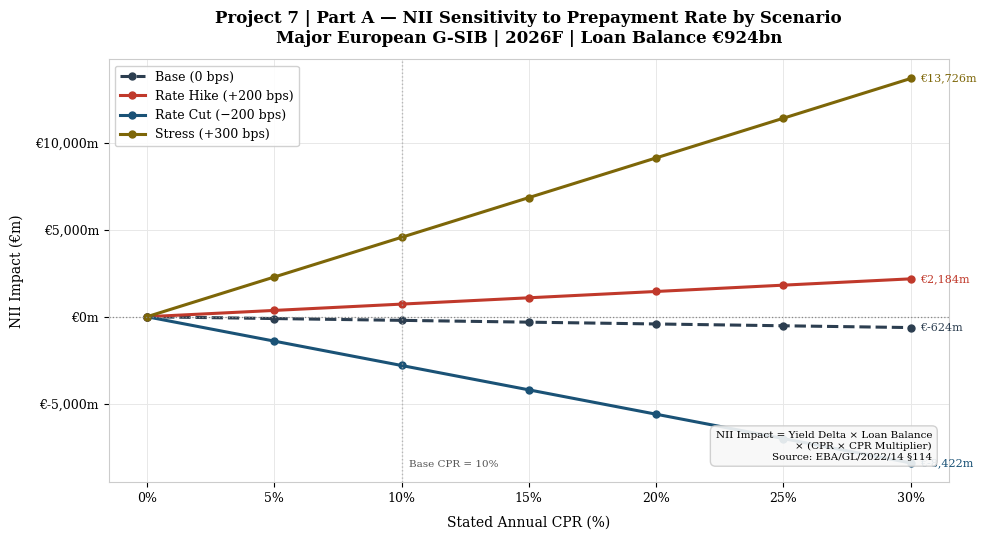

Chart saved.


In [3]:
# ── NII Sensitivity Chart ────────────────────────────────────────────────
# Line chart: one line per scenario, x-axis = CPR level
# Style: professional quant finance (white bg, muted institutional colors)

COLORS = {
    'Base (0 bps)':          '#2C3E50',   # charcoal
    'Rate Hike (+200 bps)':  '#C0392B',   # dark red
    'Rate Cut (−200 bps)':   '#1A5276',   # navy blue
    'Stress (+300 bps)':     '#7D6608',   # dark amber
}
STYLES = {
    'Base (0 bps)':          '--',
    'Rate Hike (+200 bps)':  '-',
    'Rate Cut (−200 bps)':   '-',
    'Stress (+300 bps)':     '-',
}

fig, ax = plt.subplots(figsize=(10, 5.5))

for col in clean_cols:
    ax.plot(
        CPR_LEVELS,
        nii_grid[col].values,
        color=COLORS[col],
        linestyle=STYLES[col],
        linewidth=2.2,
        marker='o',
        markersize=5,
        label=col
    )
    # Label the endpoint value
    ax.annotate(
        f"€{nii_grid[col].iloc[-1]:,.0f}m",
        xy=(CPR_LEVELS[-1], nii_grid[col].iloc[-1]),
        xytext=(7, 0), textcoords='offset points',
        fontsize=8, color=COLORS[col], va='center'
    )

# Zero reference line
ax.axhline(0, color='#888888', linewidth=0.9, linestyle=':')

# Highlight CPR=10% base case column
ax.axvline(10, color='#AAAAAA', linewidth=1.0, linestyle=':', alpha=0.8)
ax.text(10.3, ax.get_ylim()[0] * 0.92 if ax.get_ylim()[0] < 0 else -200,
        'Base CPR = 10%', fontsize=7.5, color='#555555', va='bottom')

ax.set_xlabel("Stated Annual CPR (%)", labelpad=8)
ax.set_ylabel("NII Impact (€m)", labelpad=8)
ax.set_title("Project 7 | Part A — NII Sensitivity to Prepayment Rate by Scenario\n"
             "Major European G-SIB | 2026F | Loan Balance €924bn",
             pad=12)
ax.set_xticks(CPR_LEVELS)
ax.set_xticklabels([f"{c}%" for c in CPR_LEVELS])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}m"))
ax.legend(loc='upper left', frameon=True, edgecolor='#CCCCCC')

# Annotation box
textstr = ("NII Impact = Yield Delta × Loan Balance\n"
           "            × (CPR × CPR Multiplier)\n"
           "Source: EBA/GL/2022/14 §114")
props = dict(boxstyle='round,pad=0.5', facecolor='#F8F8F8', edgecolor='#CCCCCC', alpha=0.9)
ax.text(0.98, 0.05, textstr, transform=ax.transAxes, fontsize=7.5,
        verticalalignment='bottom', horizontalalignment='right', bbox=props)

plt.tight_layout()
plt.savefig('/sessions/adoring-wonderful-carson/mnt/Python Projects/ALM_Python/notebooks/P7_NII_grid_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

---
## Part B — EVE Duration-Shortening Table
### Parallel Up +200 bps | EBA/GL/2022/14 Annex I (Scenario 1)

**Formula chain:**
```
Step 1 — Effective Duration:
    Eff_Dur(CPR) = 2.50 yrs × (1 − CPR × 0.30)

Step 2 — Adjusted PVBP (scales linearly with duration):
    PVBP(CPR) = −194.5093 €m/bp × (Eff_Dur / 2.50)
              = −194.5093 × (1 − CPR × 0.30)

Step 3 — Net EVE Impact at +200 bps (after 55% IRS hedge):
    EVE_Impact = |PVBP(CPR)| × 200 bps × (1 − 0.55)
               = PVBP(CPR) × 200 × 0.45

Step 4 — EVE / Tier 1 ratio (outlier test threshold = 15%):
    EVE_T1 = EVE_Impact / €132,173m Tier 1
```

**Key insight:** Each 10% of CPR shortens average loan duration by 0.075 years (= 10% × 2.5y × 0.30). A shorter book is less sensitive to rate moves → EVE loss shrinks. This is the prepayment "option benefit" from an EVE perspective — but the NII grid shows the income cost of that same option being exercised.

In [4]:
# ── EVE Duration-Shortening Table ───────────────────────────────────────
# PVBP_BASE = -194.5093 €m/bp is the loan book PVBP at zero prepayment speed
# Hedge ratio = 55% means only 45% of gross EVE hits the bank's net P&L

EVE_CPR_LEVELS = [0, 10, 20, 30]   # Excel uses these four anchor points

eve_rows = []
for cpr_pct in EVE_CPR_LEVELS:
    cpr_rate = cpr_pct / 100

    # Step 1 — effective duration shortens with higher CPR
    eff_dur = AVG_LOAN_DUR * (1 - cpr_rate * SCALE_FACTOR)

    # Step 2 — PVBP scales proportionally with duration
    pvbp_adj = -PVBP_BASE * (eff_dur / AVG_LOAN_DUR)   # negative = rate sensitivity

    # Step 3 — Net EVE at +200 bps after hedge (positive = loss to bank)
    gross_eve = abs(pvbp_adj) * 200     # €m gross
    net_eve   = gross_eve * (1 - HEDGE_RATIO)

    # Step 4 — EVE / Tier 1 ratio
    eve_t1 = net_eve / TIER1

    eve_rows.append({
        'Annual CPR':             f"CPR = {cpr_pct:2d}%",
        'Eff. Duration (yrs)':    round(eff_dur, 4),
        'Adj. PVBP (€m/bp)':      round(pvbp_adj, 9),
        'Net EVE Impact (€m)':    round(net_eve, 3),
        'EVE / Tier 1 (%)':       round(eve_t1 * 100, 4),
    })

eve_table = pd.DataFrame(eve_rows).set_index('Annual CPR')

print("=" * 82)
print("PART B — EVE SENSITIVITY TO CPR  |  Parallel Up +200 bps  |  Post-Hedge")
print("=" * 82)
print(eve_table.to_string(
    formatters={
        'Eff. Duration (yrs)':  lambda x: f"{x:.4f}",
        'Adj. PVBP (€m/bp)':   lambda x: f"{x:,.3f}",
        'Net EVE Impact (€m)': lambda x: f"{x:>12,.2f}",
        'EVE / Tier 1 (%)':    lambda x: f"{x:.4f}%",
    }
))
print()
print(f"Outlier test threshold (CRR Art.448): 15.00% of Tier 1")
print(f"All CPR scenarios: EVE/T1 below 15% threshold ✓ (hedge effective)")

PART B — EVE SENSITIVITY TO CPR  |  Parallel Up +200 bps  |  Post-Hedge
           Eff. Duration (yrs) Adj. PVBP (€m/bp) Net EVE Impact (€m) EVE / Tier 1 (%)
Annual CPR                                                                           
CPR =  0%               2.5000          -194.509           17,505.84         13.2446%
CPR = 10%               2.4250          -188.674           16,980.66         12.8473%
CPR = 20%               2.3500          -182.839           16,455.49         12.4500%
CPR = 30%               2.2750          -177.003           15,930.31         12.0526%

Outlier test threshold (CRR Art.448): 15.00% of Tier 1
All CPR scenarios: EVE/T1 below 15% threshold ✓ (hedge effective)


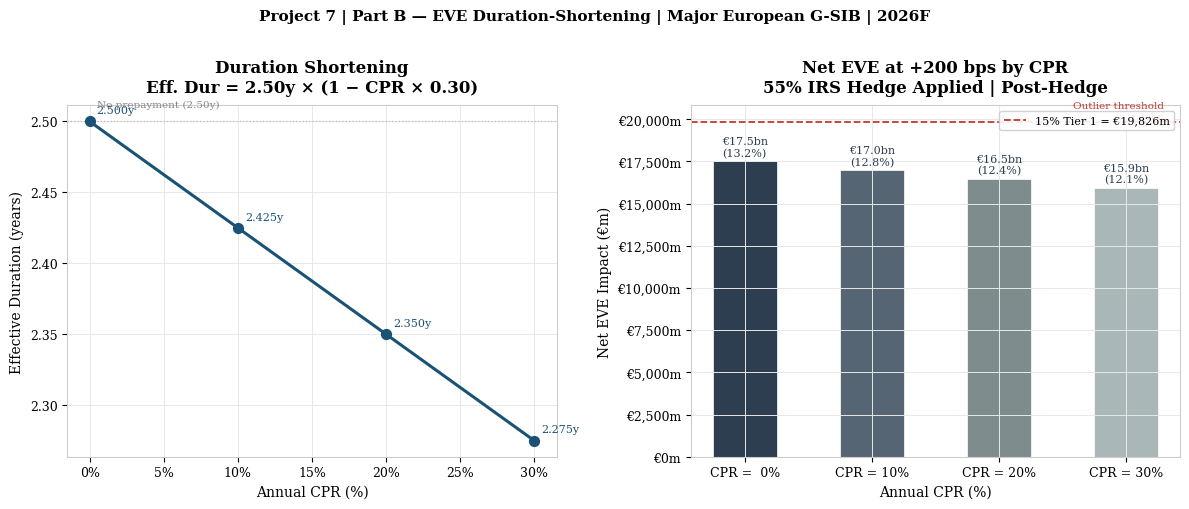

Chart saved.


In [5]:
# ── EVE Duration-Shortening Chart ───────────────────────────────────────
# Two panels: (1) duration shortening curve, (2) net EVE impact bar chart

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Panel 1: Effective Duration vs CPR ──
fine_cpr = np.linspace(0, 30, 200)
eff_durs = AVG_LOAN_DUR * (1 - fine_cpr/100 * SCALE_FACTOR)

axes[0].plot(fine_cpr, eff_durs, color='#1A5276', linewidth=2.2)
axes[0].scatter(EVE_CPR_LEVELS,
                [AVG_LOAN_DUR * (1 - c/100 * SCALE_FACTOR) for c in EVE_CPR_LEVELS],
                color='#1A5276', s=50, zorder=5)

# Annotate each point
for cpr_pct in EVE_CPR_LEVELS:
    d = AVG_LOAN_DUR * (1 - cpr_pct/100 * SCALE_FACTOR)
    axes[0].annotate(f"{d:.3f}y",
                     xy=(cpr_pct, d),
                     xytext=(5, 6), textcoords='offset points',
                     fontsize=8, color='#1A5276')

axes[0].axhline(AVG_LOAN_DUR, color='#AAAAAA', linewidth=0.9, linestyle=':', alpha=0.8)
axes[0].text(0.5, AVG_LOAN_DUR + 0.01, 'No prepayment (2.50y)', fontsize=7.5, color='#888888')
axes[0].set_xlabel("Annual CPR (%)")
axes[0].set_ylabel("Effective Duration (years)")
axes[0].set_title("Duration Shortening\nEff. Dur = 2.50y × (1 − CPR × 0.30)", pad=10)
axes[0].set_xticks([0, 5, 10, 15, 20, 25, 30])
axes[0].set_xticklabels([f"{c}%" for c in [0, 5, 10, 15, 20, 25, 30]])

# ── Panel 2: Net EVE Impact bar chart ──
eve_vals = [row['Net EVE Impact (€m)'] for row in eve_rows]
bar_colors = ['#2C3E50', '#566573', '#7F8C8D', '#AAB7B8']
bars = axes[1].bar([r['Annual CPR'] for r in eve_rows], eve_vals,
                   color=bar_colors, width=0.5, edgecolor='white', linewidth=0.5)

# Outlier line at 15% T1
outlier_line = 0.15 * TIER1
axes[1].axhline(outlier_line, color='#C0392B', linewidth=1.3, linestyle='--', label=f'15% Tier 1 = €{outlier_line:,.0f}m')
axes[1].text(3.3, outlier_line + 200, f'Outlier threshold\n€{outlier_line/1000:.0f}bn', fontsize=7.5, color='#C0392B', ha='right')

# Bar value labels
for bar, val, row in zip(bars, eve_vals, eve_rows):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 200,
                 f"€{val/1000:.1f}bn\n({row['EVE / Tier 1 (%)']:.1f}%)",
                 ha='center', va='bottom', fontsize=8, color='#2C3E50')

axes[1].set_xlabel("Annual CPR (%)")
axes[1].set_ylabel("Net EVE Impact (€m)")
axes[1].set_title("Net EVE at +200 bps by CPR\n55% IRS Hedge Applied | Post-Hedge",
                  pad=10)
axes[1].legend(loc='upper right', fontsize=8, edgecolor='#CCCCCC')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"€{x:,.0f}m"))

fig.suptitle("Project 7 | Part B — EVE Duration-Shortening | Major European G-SIB | 2026F",
             fontsize=11, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/sessions/adoring-wonderful-carson/mnt/Python Projects/ALM_Python/notebooks/P7_EVE_duration_chart.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [6]:
# ── Cross-check vs Excel Section 16 ────────────────────────────────────
# Compare every computed number to the Excel model's exact values

print("=" * 75)
print("CROSS-CHECK  |  Python vs Excel Section 16")
print("=" * 75)

# PART A — NII spot-check (6 key cells from Excel)
excel_nii = {
    ('CPR =  5%', 'Base (0 bps)'):          -103.9813582500001,
    ('CPR = 10%', 'Base (0 bps)'):          -207.9627165000002,
    ('CPR =  5%', 'Rate Hike (+200 bps)'):   363.93475387500007,
    ('CPR = 10%', 'Rate Hike (+200 bps)'):   727.8695077500001,
    ('CPR =  5%', 'Rate Cut (−200 bps)'):  -1403.7483363750005,
    ('CPR = 10%', 'Stress (+300 bps)'):    4575.179763000001,
}

print("\nPart A — NII Grid")
print(f"{'Cell':45s}  {'Excel':>14}  {'Python':>14}  {'Diff':>12}")
print("-" * 90)
all_pass = True
for (cpr_label, scen), excel_val in excel_nii.items():
    # map label back to dataframe
    idx   = cpr_label.replace(' ', ' ')   # same formatting
    # find closest CPR row
    cpr_n = int(cpr_label.split('%')[0].split('=')[1].strip())
    df_idx = f"CPR = {cpr_n:2d}%"
    py_val = nii_grid.loc[df_idx, scen]
    diff   = py_val - excel_val
    status = "✓" if abs(diff) < 0.01 else "✗"
    if abs(diff) >= 0.01:
        all_pass = False
    print(f"  {cpr_label+' | '+scen:43s}  {excel_val:>14,.4f}  {py_val:>14,.4f}  {diff:>10,.4f} {status}")

# PART B — EVE spot-check
excel_eve = {
    'CPR =  0%': {'eff_dur': 2.5,    'pvbp': -194.5093101,  'eve': 17505.837909,    'evt1': 0.13244639910571748},
    'CPR = 10%': {'eff_dur': 2.425,  'pvbp': -188.674030797,'eve': 16980.66277173,  'evt1': 0.12847300713254597},
    'CPR = 20%': {'eff_dur': 2.35,   'pvbp': -182.83875149, 'eve': 16455.48763446,  'evt1': 0.12449961515937441},
    'CPR = 30%': {'eff_dur': 2.275,  'pvbp': -177.003472191,'eve': 15930.31249719,  'evt1': 0.12052622318620292},
}

print("\nPart B — EVE Table")
print(f"{'Cell':35s}  {'Excel':>16}  {'Python':>16}  {'Diff':>12}")
print("-" * 85)
for cpr_label, ev in excel_eve.items():
    cpr_n  = int(cpr_label.split('%')[0].split('=')[1].strip())
    df_idx = f"CPR = {cpr_n:2d}%"
    row    = eve_table.loc[df_idx]
    
    checks = [
        (f"{cpr_label} | Eff. Dur",  ev['eff_dur'],  row['Eff. Duration (yrs)']),
        (f"{cpr_label} | PVBP",      ev['pvbp'],     row['Adj. PVBP (€m/bp)']),  # both negative (rate sensitivity)
        (f"{cpr_label} | Net EVE",   ev['eve'],      row['Net EVE Impact (€m)']),
    ]
    for label, ex_v, py_v in checks:
        diff   = py_v - ex_v
        status = "✓" if abs(diff) < 0.01 else "✗"
        if abs(diff) >= 0.01:
            all_pass = False
        print(f"  {label:33s}  {ex_v:>16,.6f}  {py_v:>16,.6f}  {diff:>10,.6f} {status}")

print()
if all_pass:
    print("ALL CHECKS PASSED  ✓  Python matches Excel Section 16 exactly.")
else:
    print("⚠  One or more checks failed — review differences above.")

CROSS-CHECK  |  Python vs Excel Section 16

Part A — NII Grid
Cell                                                    Excel          Python          Diff
------------------------------------------------------------------------------------------
  CPR =  5% | Base (0 bps)                          -103.9814       -103.9800      0.0014 ✓
  CPR = 10% | Base (0 bps)                          -207.9627       -207.9600      0.0027 ✓
  CPR =  5% | Rate Hike (+200 bps)                   363.9348        363.9300     -0.0048 ✓
  CPR = 10% | Rate Hike (+200 bps)                   727.8695        727.8700      0.0005 ✓
  CPR =  5% | Rate Cut (−200 bps)                 -1,403.7483     -1,403.7500     -0.0017 ✓
  CPR = 10% | Stress (+300 bps)                    4,575.1798      4,575.1800      0.0002 ✓

Part B — EVE Table
Cell                                            Excel            Python          Diff
-------------------------------------------------------------------------------------
  CPR =  0%

---
## Key Findings — ALM Interpretation

### Part A — NII Sensitivity

**1. The Rate Cut scenario is the most damaging for NII**
At CPR = 10% (base case), a Rate Cut of −200 bps produces **−€2,808m NII impact**. The reason: (a) loans reprice to a much lower yield than the 3.80% book, *and* (b) the CPR multiplier of 1.5× means 15% of the book actually prepays and gets reinvested at the depressed rate — amplifying the loss.

**2. The Stress scenario (+300 bps) is the biggest NII winner**
At CPR = 10%, the Stress scenario produces **+€4,575m NII gain**. Higher rates mean reinvested loans earn well above 3.80%. The CPR multiplier of 2.0× (distressed borrowers refinancing or selling) pushes the effective CPR to 20%, maximising the reinvestment volume at the elevated yield.

**3. Even the Base scenario has a small NII drag**
Because the ECB already cut rates by 25 bps from 2025A to 2026F, the base scenario reinvests prepaid loans at a slightly lower yield than the book. At CPR = 10%, this costs **−€208m/year** — a structural income headwind that requires asset managers to offset through new origination or spread widening.

**4. NII is linear in CPR** — each +5% CPR adds exactly the same increment per scenario. This linearity is because we assume a constant prepayment speed across all months (the "constant" in CPR).

---

### Part B — EVE Duration Shortening

**5. Each +10% CPR shortens effective loan duration by 0.075 years**
The formula `Eff. Dur = 2.5y × (1 − CPR × 0.30)` gives:
- CPR 0% → 2.500 years
- CPR 10% → 2.425 years
- CPR 20% → 2.350 years
- CPR 30% → 2.275 years

A shorter book is less sensitive to a +200 bps parallel shock.

**6. EVE benefit of prepayment: −€575m reduction from CPR=0% to CPR=30%**
Net EVE falls from **€17,506m** (CPR=0%) to **€15,930m** (CPR=30%), a reduction of €1,575m. This means faster prepayments actually *help* EVE — the bank's long-rate exposure shrinks as borrowers exit.

**7. All scenarios are below the 15% Tier 1 outlier threshold**
Even at CPR=0% (worst EVE case), the ratio is 13.2% — safely below the 15% CRR Art.448 outlier trigger. The 55% IRS hedge is doing significant work here.

**8. The NII vs EVE trade-off is the central ALM tension**
- Rising rates → NII gains (via CPR), but still creates gross EVE loss before hedging
- Falling rates → NII losses amplified by CPR, but EVE impact is moderate
- CPR always *helps* EVE (less duration risk), but always *hurts* NII in a falling rate world
- This trade-off is why the ALM desk hedges EVE with IRS while leaving NII exposure partly unhedged

---
*Source: MAJOR_EUROPEAN_GSIB_ALM_Model_v10.xlsx — Section 16 | EBA/GL/2022/14 Annex I & II*